In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

In [2]:
import os

data_root_dir = os.path.join(os.getcwd(), 'bfm_output', 'lorenz_current_coarse_mesh')
print(data_root_dir)

def load_data():
    total_data = []
    
    for dirname in os.listdir(data_root_dir):
        if dirname.endswith('.npy') or dirname.endswith('.json'):
            continue
        if dirname == 'img':
            continue
        params = dirname.replace("p", ".").split("_")
        data = {params[2*i]: float(params[2*i+1]) for i in range(len(params)//2)}
        data['dirname'] = dirname
        data['output'] = np.load(os.path.join(data_root_dir, dirname, 'model_outputs.npy'))
        data['v_trace'] = np.load(os.path.join(data_root_dir, dirname, 'model_v_traces.npy'))
        data['dec_trace'] = np.load(os.path.join(data_root_dir, dirname, 'model_decoders.npy'))
        total_data.append(data)
    return total_data

/home/ali/Code/ml-force/hpc/bfm_output/lorenz_current_coarse_mesh


In [3]:
total_data = load_data()

total_data

[{'Q': 150.0,
  'gbar': 40.0,
  'dirname': 'Q_150p0000_gbar_40p0000',
  'output': array([[ 0.        ,  0.        ,  0.        ],
         [ 0.        ,  0.        ,  0.        ],
         [ 0.        ,  0.        ,  0.        ],
         ...,
         [-0.01164192,  0.00526933, -0.24847397],
         [-0.01164418,  0.00509217, -0.24835902],
         [-0.01164881,  0.00491195, -0.24824351]], dtype=float32),
  'v_trace': array([[-2.3755005e-01,  4.9756312e-01, -3.0441132e-01, ...,
           3.7522393e-01,  5.4228836e-01,  2.3813782e-02],
         [-4.8036337e-01,  1.0107005e+00, -6.1054808e-01, ...,
           7.5747442e-01,  1.0977458e+00,  4.1775923e-02],
         [-7.2909790e-01,  1.5395478e+00, -9.1861367e-01, ...,
           1.1467437e+00,  1.6665571e+00,  5.4267857e-02],
         ...,
         [-4.3579361e+01, -4.4907219e+01, -3.7713188e+01, ...,
          -5.5541672e+01, -3.5812998e-01, -2.7584003e+01],
         [-4.3621407e+01, -4.4846592e+01, -3.7687199e+01, ...,
          -5.

(500000, 3)


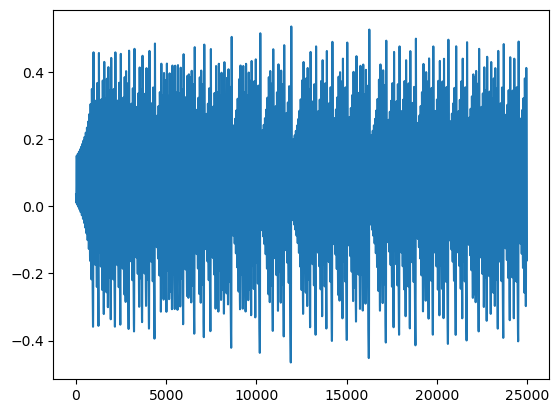

In [4]:
import sys

sys.path.append(os.path.join(os.getcwd(), '..'))

from ml_force import LorenzAttractor, minmax_transform, z_transform

seed = 1
np.random.seed(seed)

T = 25_000
dt = 5e-2
t = np.arange(0, T, dt)
nt = t.size
la = LorenzAttractor(T, dt, tau=.01)
x = la.generate(transient_time=500.0)

x = x.T
sup = minmax_transform(x, zero_mean=True)
sup = np.load(os.path.join(data_root_dir, 'supervisor.npy'))
# sup = z_transform(x)
print(sup.shape)

plt.plot(t, sup[:, 2])
plt.show()

In [5]:
from scipy.signal import find_peaks

rls_stop = T - 10_000

test_start = round(rls_stop // dt)

def get_return_map(data):
    peaks = data[find_peaks(data, distance=1000)[0]]
    # peaks = peaks[peaks > 0]
    return_map = np.vstack([peaks[:-1], peaks[1:]])
    return return_map

In [6]:
for data in total_data:
    data['return_map'] = get_return_map(data['output'][test_start:, 2])   # The z-axis of the lorenz system is used for the return map

In [7]:
total_sorted = sorted(total_data, key=lambda x: x['Q'])

def sort_stacked(total_sorted):
    total_stacked = []
    Qs = [data['Q'] for data in total_sorted]
    for value in np.unique(Qs):
        dummy = list()
        for data in total_sorted:
            if data['Q'] == value:
                dummy.append(data)
        total_stacked.append(sorted(dummy, key=lambda x: x['gbar']))

    for lst in total_stacked:
        for data in lst:
            print(data['Q'], data['gbar'])
    return total_stacked

total_stacked = sort_stacked(total_sorted)

150.0 15.0
150.0 20.0
150.0 25.0
150.0 30.0
150.0 35.0
150.0 40.0
150.0 45.0
150.0 50.0
190.0 15.0
190.0 20.0
190.0 25.0
190.0 30.0
190.0 35.0
190.0 40.0
190.0 45.0
190.0 50.0
230.0 15.0
230.0 20.0
230.0 25.0
230.0 30.0
230.0 35.0
230.0 40.0
230.0 45.0
230.0 50.0
270.0 15.0
270.0 20.0
270.0 25.0
270.0 30.0
270.0 35.0
270.0 40.0
270.0 45.0
270.0 50.0
310.0 15.0
310.0 20.0
310.0 25.0
310.0 30.0
310.0 35.0
310.0 40.0
310.0 45.0
310.0 50.0
350.0 15.0
350.0 20.0
350.0 25.0
350.0 30.0
350.0 35.0
350.0 40.0
350.0 45.0
350.0 50.0


In [8]:
cwd = os.getcwd()

save_dir = os.path.join(cwd, 'bfm_output', 'lorenz_current_coarse_mesh', 'img')

if not os.path.exists(save_dir):
    os.makedirs(save_dir)

In [9]:
original_return_map = get_return_map(sup[test_start:, 2])

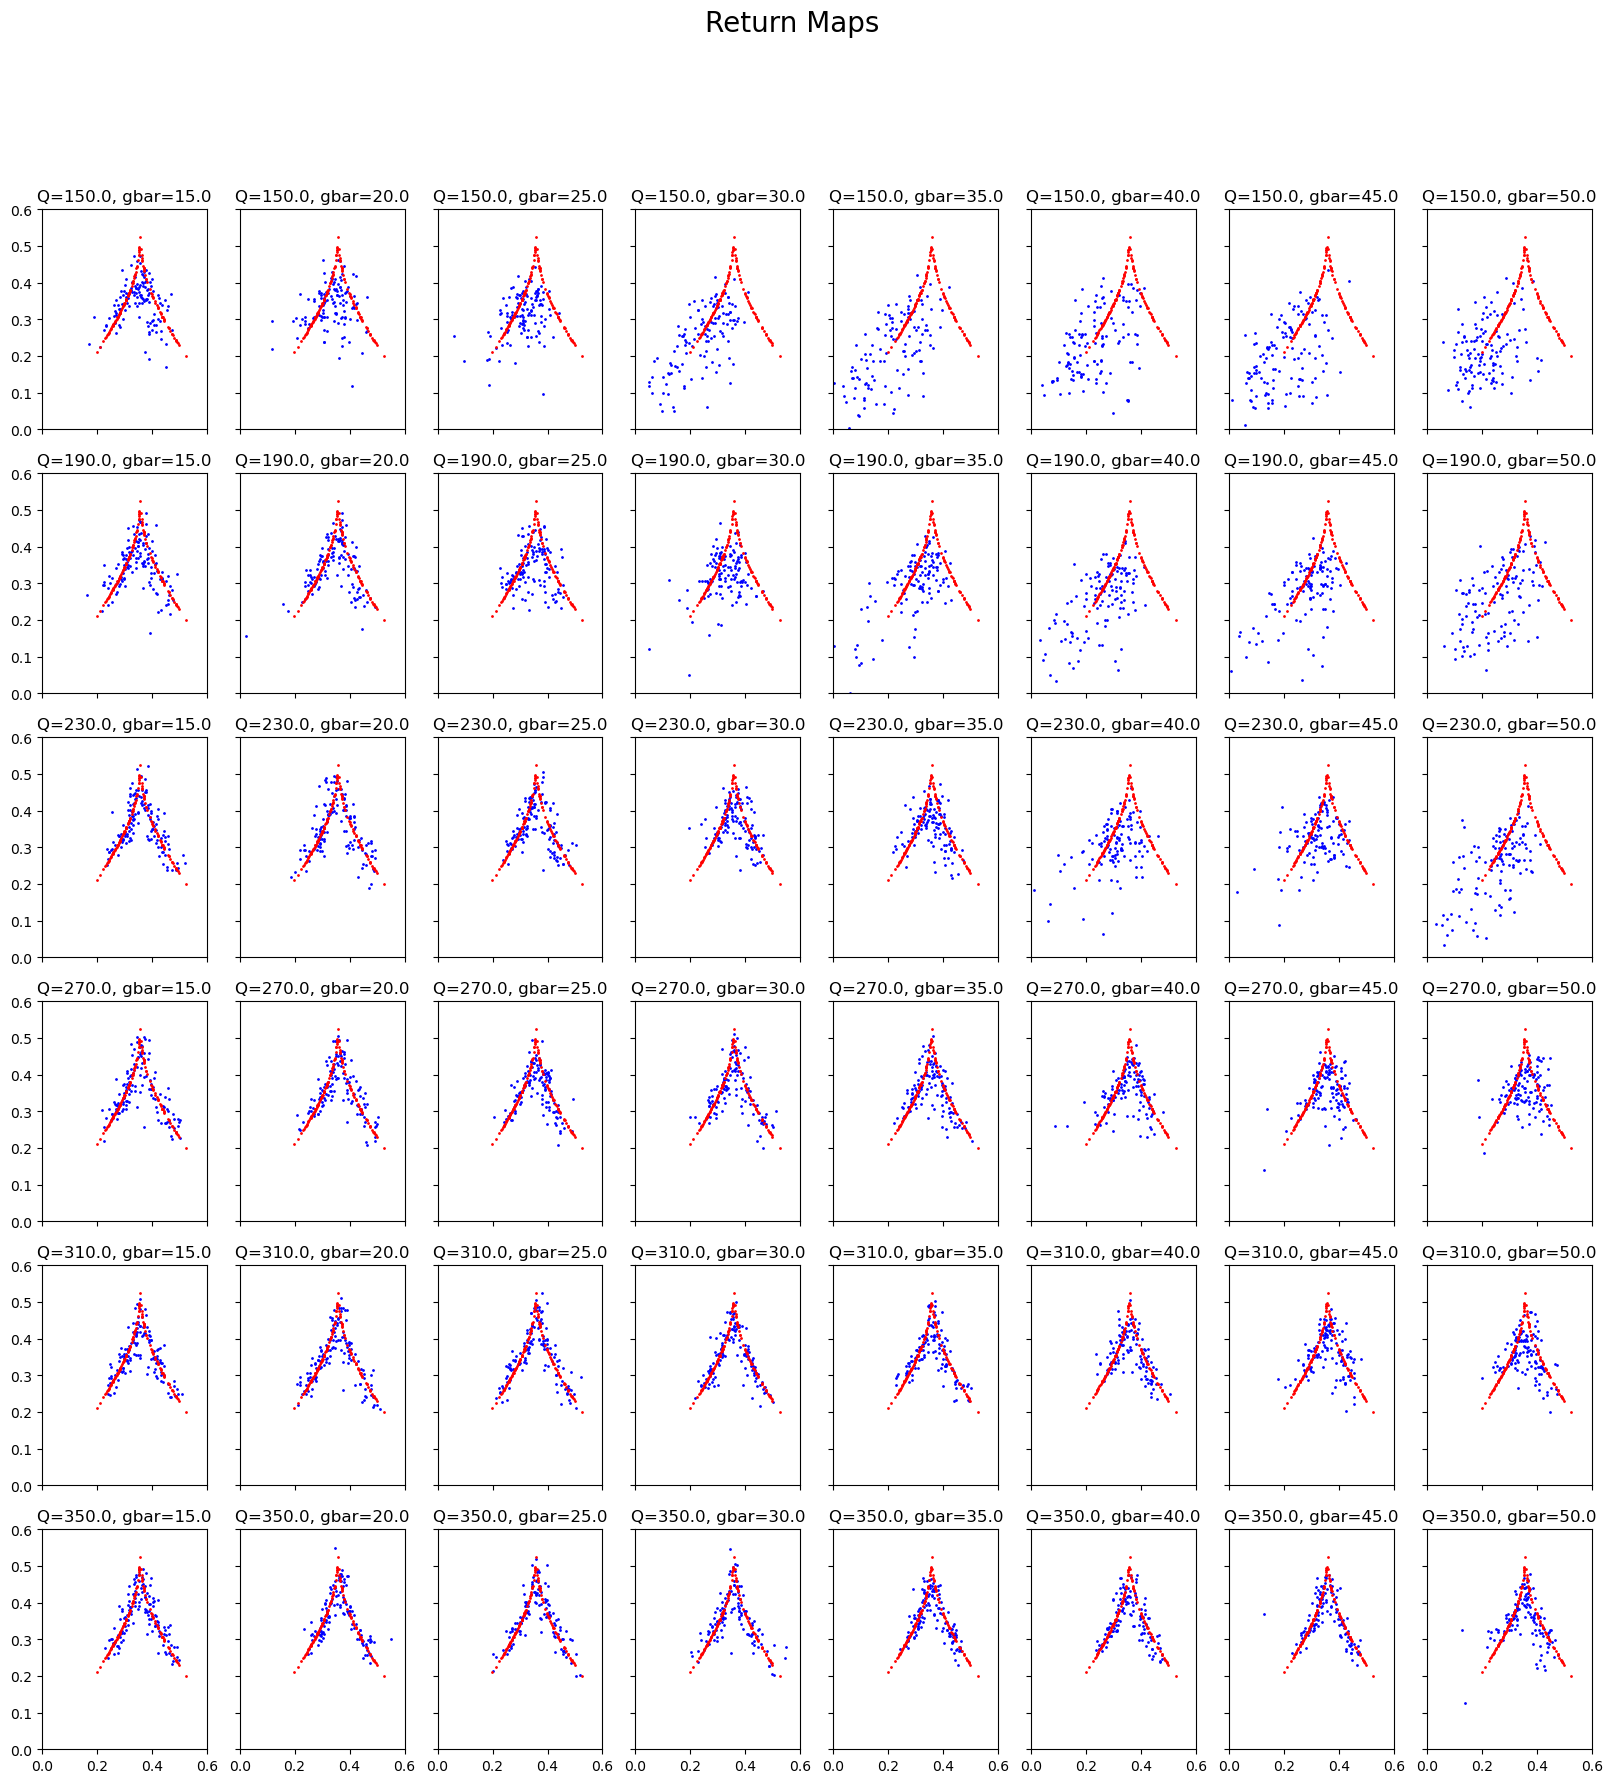

In [10]:
fig, ax = plt.subplots(len(total_stacked), len(total_stacked[0]), figsize=(20, 20), sharex=True, sharey=True)

for i in range(len(total_stacked)):
    for j in range(len(total_stacked[i])):
        data = total_stacked[i][j]
        ax[i, j].scatter(data['return_map'][0], data['return_map'][1], c='b', s=1)
        ax[i, j].scatter(original_return_map[0], original_return_map[1], c='r', s=1)
        ax[i, j].set_title(f"Q={data['Q']}, gbar={data['gbar']}")
plt.xlim(0, 0.6)
plt.ylim(0, 0.6)
plt.suptitle("Return Maps", fontsize=20)
plt.savefig(os.path.join(save_dir, 'return_maps.png'), dpi=300, bbox_inches='tight')
plt.show()

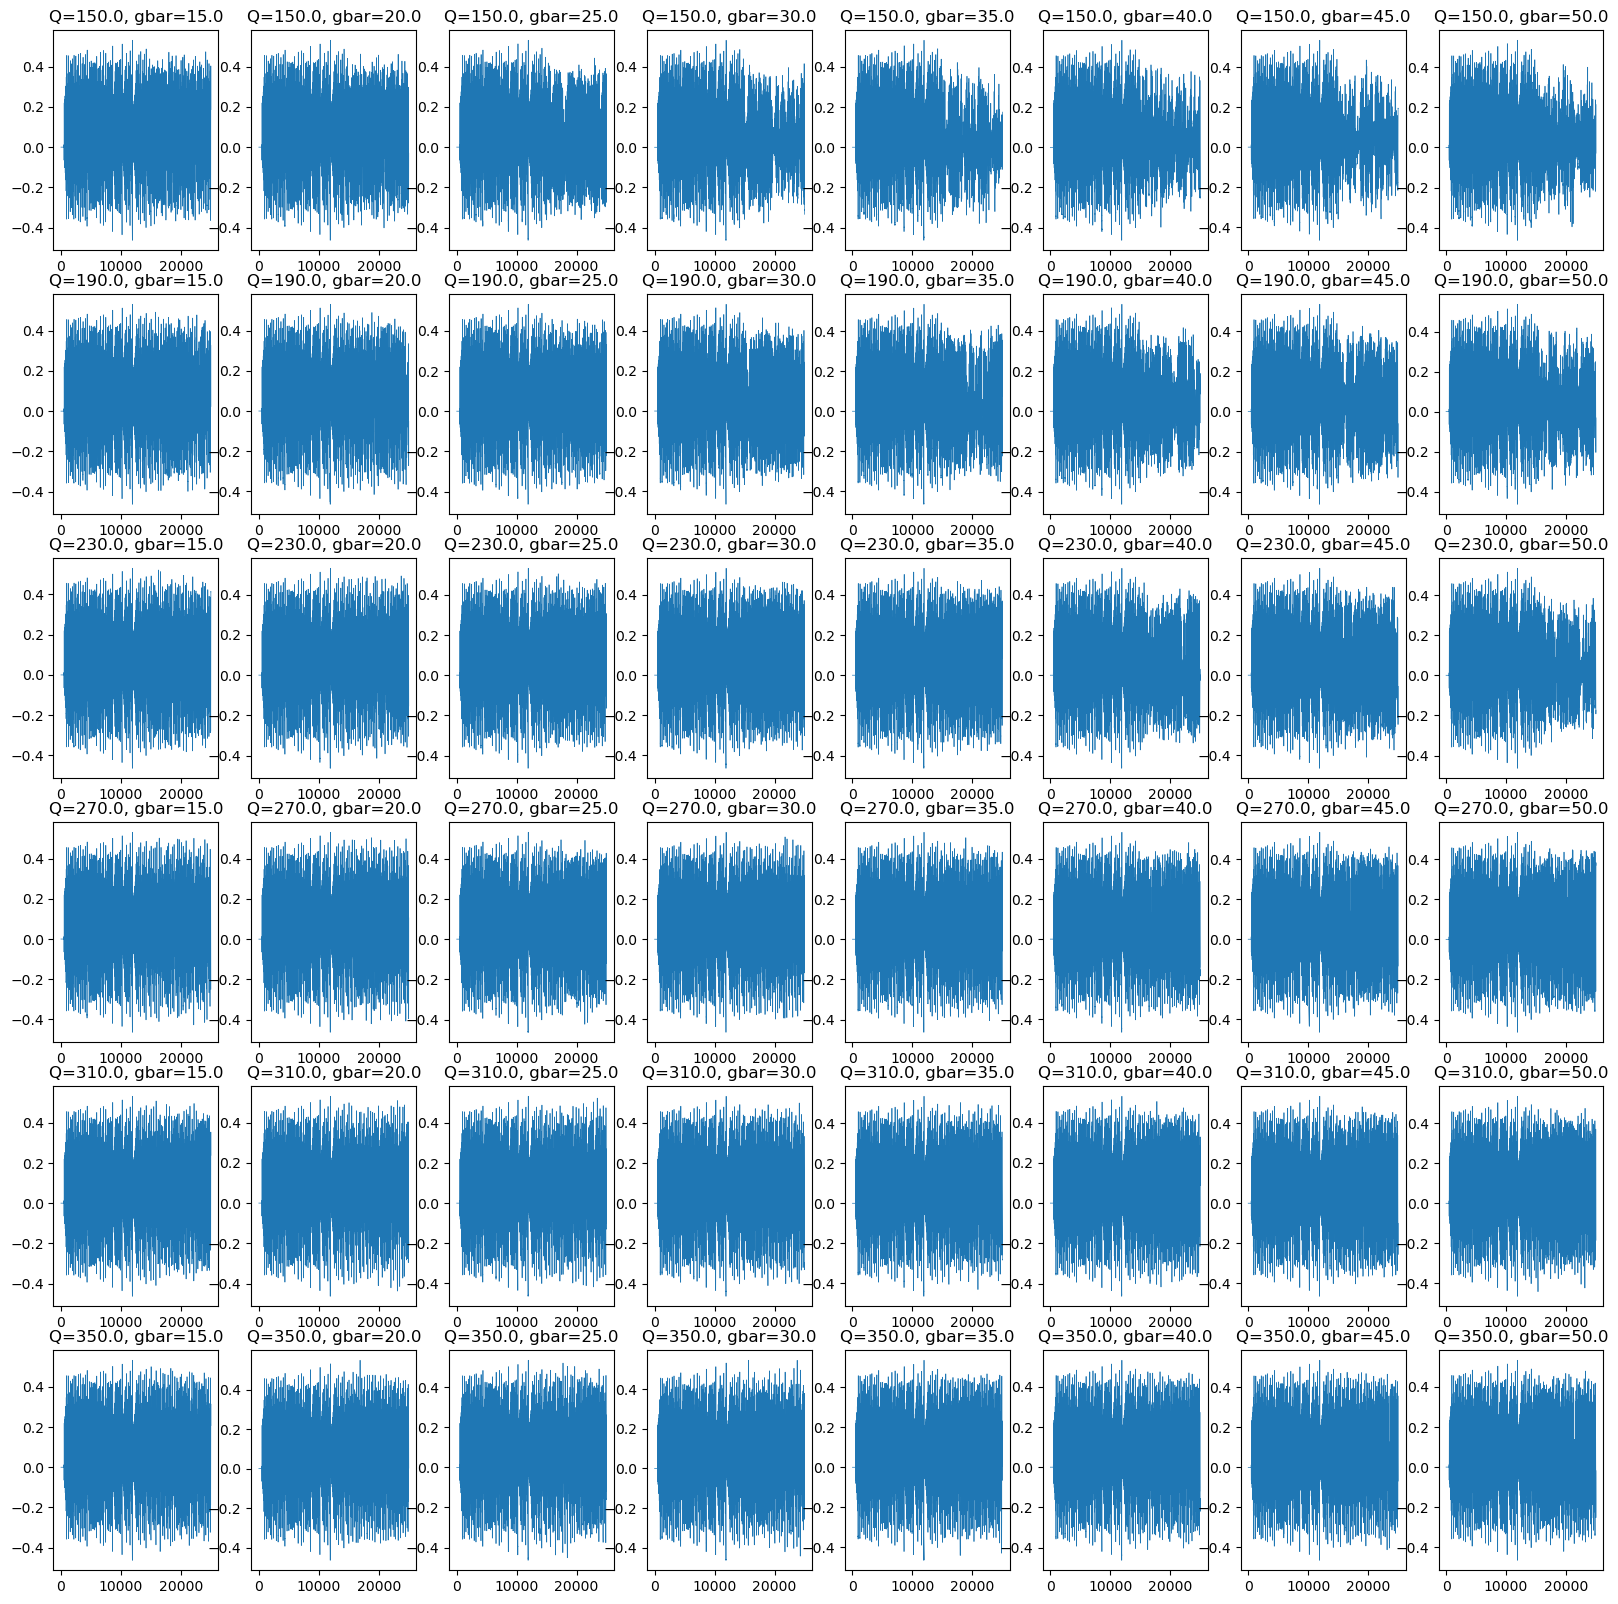

In [11]:
t = np.arange(total_data[0]['output'].shape[0]) * dt
fig, ax = plt.subplots(len(total_stacked), len(total_stacked[0]), figsize=(20, 20))

for i in range(len(total_stacked)):
    for j in range(len(total_stacked[i])):
        data = total_stacked[i][j]
        ax[i, j].plot(t, data['output'][:, 2], lw=.5)
        ax[i, j].set_title(f"Q={data['Q']}, gbar={data['gbar']}")
plt.savefig(os.path.join(save_dir, 'x_time_series.png'), dpi=300, bbox_inches='tight')
plt.show()

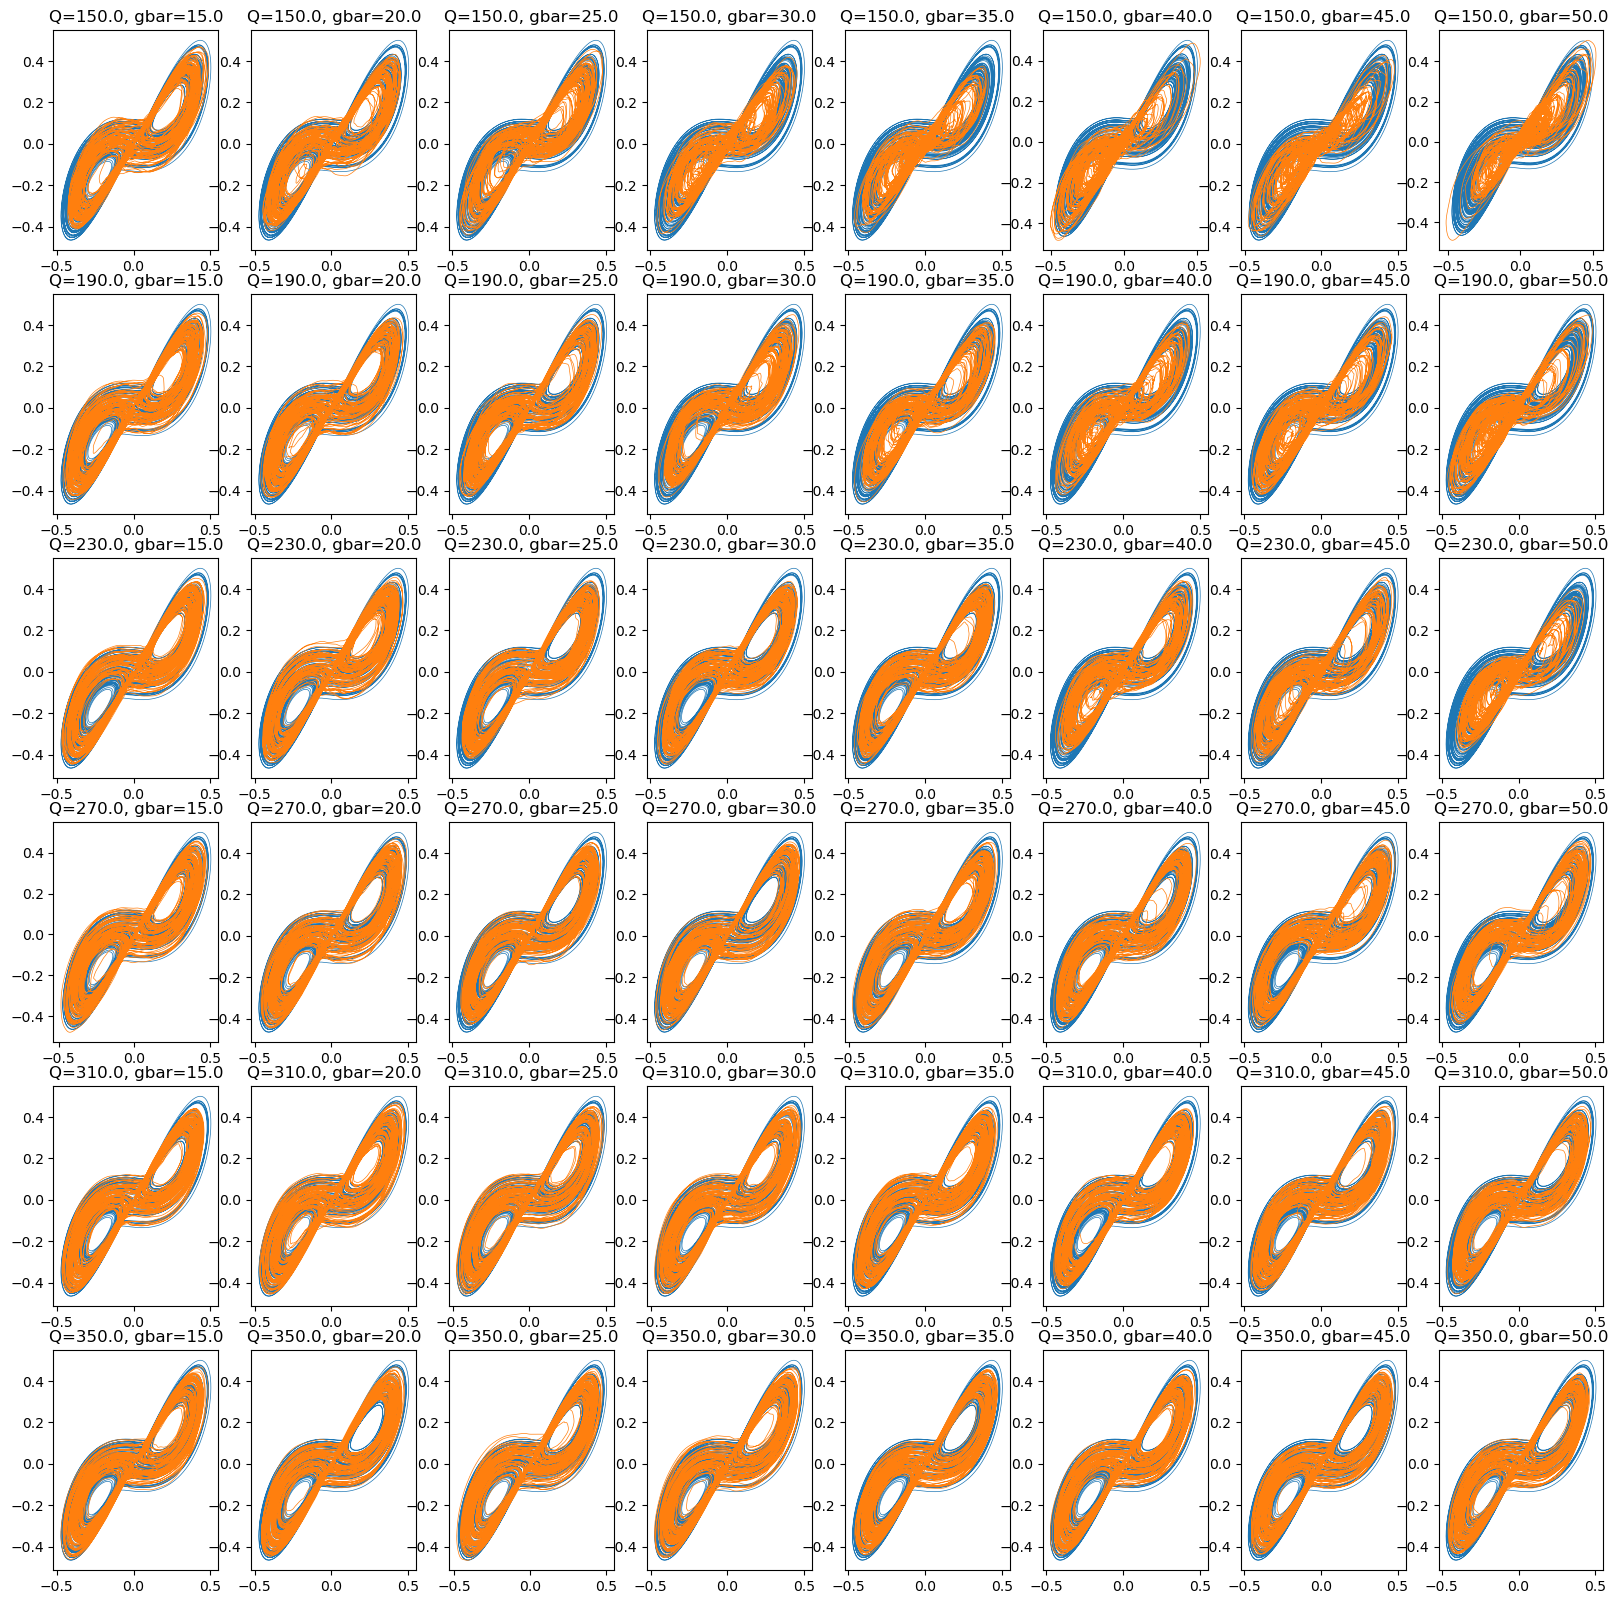

In [12]:
fig, ax = plt.subplots(len(total_stacked), len(total_stacked[0]), figsize=(20, 20))

for i in range(len(total_stacked)):
    for j in range(len(total_stacked[i])):
        data = total_stacked[i][j]
        ax[i, j].plot(sup[test_start:, 0], sup[test_start:, 1], lw=.5)
        ax[i, j].plot(data['output'][test_start:, 0], data['output'][test_start:, 1], lw=.5)
        ax[i, j].set_title(f"Q={data['Q']:.1f}, gbar={data['gbar']:.1f}")

plt.savefig(os.path.join(save_dir, 'x_y_phase_space.png'), dpi=300, bbox_inches='tight')
plt.show()

In [11]:
from typing import Union

def mean_squared_density_difference(data1, data2, axis:int=1, bins:Union[int, str, np.ndarray]=100):
    hists1 = np.array([np.histogram(data1[:, i], bins=bins, density=True)[0] for i in range(data1.shape[axis])])
    hists2 = np.array([np.histogram(data2[:, i], bins=bins, density=True)[0] for i in range(data2.shape[axis])])
    
    return np.mean((hists1 - hists2) ** 2)

In [12]:
axis = 1

mean_squared_density_difference(sup[test_start:, :], total_stacked[4][3]['output'][test_start:, :], axis=axis, bins=np.linspace(-.5, .5, 100))


0.07248272795828607

In [18]:
bins = np.linspace(-.5, .5, 201)
losses = [[mean_squared_density_difference(sup[test_start:, :], data['output'][test_start:, :], axis=axis, bins=bins) for data in lst] for lst in total_stacked]

losses = np.array(losses)

print(losses)
where = np.where(losses == np.min(losses))

print(where)
print(losses[where])

[[0.07127494 0.09848987 0.14896705 0.19649911 0.35981478 0.55305657
  0.37680101 0.34245318]
 [0.04849555 0.07814739 0.13632812 0.14797298 0.24215352 0.21416935
  0.20618714 0.46096308]
 [0.06397962 0.04217308 0.05275758 0.08876848 0.07583988 0.16834825
  0.22262067 0.46496798]
 [0.03995005 0.08836717 0.10458364 0.16278232 0.0743862  0.11087949
  0.10325424 0.14191537]
 [0.04896065 0.04352381 0.06387783 0.08142212 0.05888676 0.07166279
  0.09399743 0.11757383]
 [0.0707312  0.06515813 0.04895356 0.05308303 0.08927958 0.05263392
  0.07920773 0.07694338]]
(array([3]), array([0]))
[0.03995005]


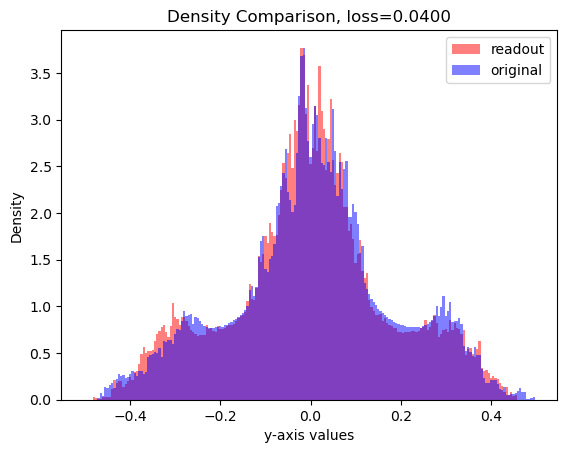

0.039950052469451054


In [17]:
hist, _ = np.histogram(total_stacked[where[0][0]][where[1][0]]['output'][test_start:, 1], bins=bins, density=True)
hist1, _ = np.histogram(sup[test_start:, 1], bins=bins, density=True)
plt.bar(bins[:-1], hist, width=bins[1]-bins[0], color='r', alpha=.5, label="readout")
plt.bar(bins[:-1], hist1, width=bins[1]-bins[0], color='b', alpha=.5, label="original")
plt.legend(loc=0)
plt.xlabel("y-axis values")
plt.ylabel("Density")
plt.title(f"Density Comparison, loss={losses[where[0][0], where[1][0]]:.4f}")
plt.savefig(os.path.join(save_dir, 'density_comparison.png'), dpi=300, bbox_inches='tight')
plt.show()
print(mean_squared_density_difference(sup[test_start:, :], total_stacked[3][0]['output'][test_start:, :], axis=axis, bins=bins))

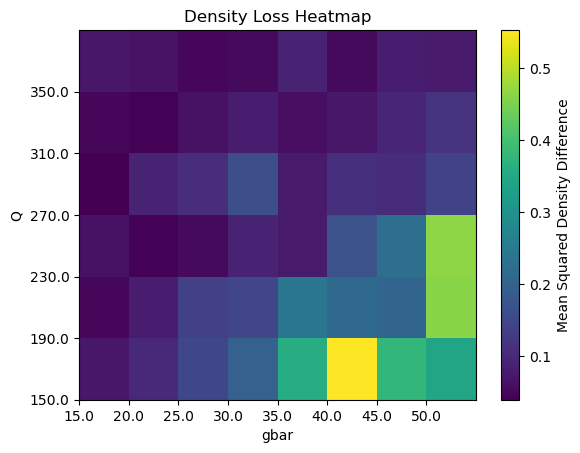

In [22]:
plt.pcolormesh(losses, cmap='viridis')
plt.colorbar(label="Mean Squared Density Difference")
plt.xticks(np.arange(losses.shape[1]), [data['gbar'] for data in total_stacked[0]])
plt.yticks(np.arange(losses.shape[0]), [data[0]['Q'] for data in total_stacked])
plt.xlabel("gbar")
plt.ylabel("Q")
plt.title("Density Loss Heatmap")
plt.savefig(os.path.join(save_dir, 'density_loss_heatmap.png'), dpi=300, bbox_inches='tight')
plt.show()